<a href="https://colab.research.google.com/github/jayden14141/Network-Anomaly-Detection/blob/main/ml/notebooks/04_ovr_medium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    df = pd.read_csv('/content/drive/MyDrive/cicids2017_cleaned.csv')
    with open('/content/drive/MyDrive/attack_features.json') as f:
        attack_features = json.load(f)
    with open('/content/drive/MyDrive/attack_groups.json') as f:
        groups = json.load(f)
    print(f"Loaded from Drive: {df.shape}")
except Exception as e:
    print(f"Drive mount failed: {e}")

Mounted at /content/drive
Loaded from Drive: (2827876, 79)


In [ ]:
# --- Config ---
LABEL_COL     = 'Label'
BENIGN_RATIO  = 5
TEST_SIZE     = 0.20
CV_SPLITS     = 3
RANDOM_STATE  = 42
AE_EPOCHS     = 10
AE_BATCH      = 256
AE_THRESHOLD_PERCENTILE = 95
MAX_ATTACK_SAMPLES = 50_000
OUTPUT_RESULTS = '/content/drive/MyDrive/results_medium.json'

In [ ]:
medium_attacks = groups['medium']
print(f"Medium attacks: {medium_attacks}")
for a in medium_attacks:
    print(f"  {a:<20s}: {(df[LABEL_COL] == a).sum():>7,}")

Medium attacks: ['FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'Bot', 'Web Attack - Brute Force']
  FTP-Patator         :   7,935
  SSH-Patator         :   5,897
  DoS slowloris       :   5,796
  DoS Slowhttptest    :   5,499
  Bot                 :   1,956
  Web Attack - Brute Force:   1,507


In [ ]:
from sklearn.model_selection import train_test_split

def build_ovr_dataset(df, attack, features):
    attack_mask = df[LABEL_COL] == attack
    benign_mask = df[LABEL_COL] == 'BENIGN'

    rng = np.random.RandomState(RANDOM_STATE)

    attack_idx = df.index[attack_mask].to_numpy()
    if len(attack_idx) > MAX_ATTACK_SAMPLES:
        attack_idx = rng.choice(attack_idx, size=MAX_ATTACK_SAMPLES, replace=False)

    n_benign_target = len(attack_idx) * BENIGN_RATIO
    benign_idx = df.index[benign_mask].to_numpy()
    if len(benign_idx) > n_benign_target:
        benign_idx = rng.choice(benign_idx, size=n_benign_target, replace=False)

    combined_idx = np.concatenate([benign_idx, attack_idx])
    subset = df.loc[combined_idx]
    X = subset[features].copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    y = (subset[LABEL_COL] == attack).astype(int).values

    return train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )

In [ ]:
def train_rf(X_tr, y_tr):
    m = RandomForestClassifier(
        n_estimators=200, max_depth=15, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE
    )
    m.fit(X_tr, y_tr)
    return m

def train_xgb(X_tr, y_tr):
    pos = (y_tr == 1).sum()
    neg = (y_tr == 0).sum()
    m = xgb.XGBClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        scale_pos_weight=neg / max(pos, 1),
        eval_metric='logloss', n_jobs=-1,
        random_state=RANDOM_STATE, verbosity=0
    )
    m.fit(X_tr, y_tr)
    return m

def train_lgb(X_tr, y_tr):
    m = lgb.LGBMClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
    )
    m.fit(X_tr, y_tr)
    return m

def train_autoencoder(X_tr, y_tr):
    scaler = StandardScaler()
    X_benign = X_tr[y_tr == 0]
    X_scaled = scaler.fit_transform(X_benign)

    dim = X_scaled.shape[1]
    inp = layers.Input(shape=(dim,))
    enc = layers.Dense(dim // 2, activation='relu')(inp)
    enc = layers.Dense(max(dim // 4, 2), activation='relu')(enc)
    dec = layers.Dense(dim // 2, activation='relu')(enc)
    out = layers.Dense(dim, activation='linear')(dec)
    ae = Model(inp, out)
    ae.compile(optimizer='adam', loss='mse')
    ae.fit(X_scaled, X_scaled, epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)

    recon = ae.predict(X_scaled, verbose=0)
    errors = np.mean((X_scaled - recon) ** 2, axis=1)
    threshold = np.percentile(errors, AE_THRESHOLD_PERCENTILE)
    return {'model': ae, 'scaler': scaler, 'threshold': threshold}

def predict_autoencoder(ae_bundle, X):
    X_scaled = ae_bundle['scaler'].transform(X)
    recon = ae_bundle['model'].predict(X_scaled, verbose=0)
    errors = np.mean((X_scaled - recon) ** 2, axis=1)
    return (errors > ae_bundle['threshold']).astype(int)

In [ ]:
from sklearn.model_selection import StratifiedKFold

def evaluate(y_true, y_pred):
    return {
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }

MODELS = {
    'RF':       (train_rf,          lambda m, X: m.predict(X)),
    'XGBoost':  (train_xgb,         lambda m, X: m.predict(X)),
    'LightGBM': (train_lgb,         lambda m, X: m.predict(X)),
    'AE':       (train_autoencoder, predict_autoencoder),
}

results = {}

for attack in medium_attacks:
    print(f"\n{'='*60}\n[{attack}]\n{'='*60}")
    feats = attack_features[attack]
    X_train, X_test, y_train, y_test = build_ovr_dataset(df, attack, feats)
    print(f"  Train: {len(X_train):,}  Test: {len(X_test):,}")
    print(f"  Train attack rate: {y_train.mean():.3f}  Test: {y_test.mean():.3f}")

    results[attack] = {}
    skf = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    for model_name, (train_fn, predict_fn) in MODELS.items():
        t0 = time.time()

        cv_scores = {'recall': [], 'precision': [], 'f1': []}
        for tr_idx, val_idx in skf.split(X_train, y_train):
            try:
                m = train_fn(X_train.iloc[tr_idx], y_train[tr_idx])
                preds = predict_fn(m, X_train.iloc[val_idx])
                s = evaluate(y_train[val_idx], preds)
                for k in cv_scores:
                    cv_scores[k].append(s[k])
            except Exception as e:
                print(f"    CV fold failed ({model_name}): {e}")

        m_final = train_fn(X_train, y_train)
        y_pred_test = predict_fn(m_final, X_test)
        test = evaluate(y_test, y_pred_test)

        elapsed = time.time() - t0
        results[attack][model_name] = {
            'cv_recall_mean': float(np.mean(cv_scores['recall'])),
            'cv_recall_std':  float(np.std(cv_scores['recall'])),
            'cv_f1_mean':     float(np.mean(cv_scores['f1'])),
            'test_recall':    float(test['recall']),
            'test_precision': float(test['precision']),
            'test_f1':        float(test['f1']),
            'elapsed_sec':    round(elapsed, 1),
        }
        print(f"  {model_name:<10s} "
              f"CV recall={np.mean(cv_scores['recall']):.3f}±{np.std(cv_scores['recall']):.3f}  "
              f"Test recall={test['recall']:.3f}  F1={test['f1']:.3f}  ({elapsed:.1f}s)")


[FTP-Patator]
  Train: 38,088  Test: 9,522
  Train attack rate: 0.167  Test: 0.167
  RF         CV recall=1.000±0.000  Test recall=0.999  F1=0.998  (9.0s)
  XGBoost    CV recall=1.000±0.001  Test recall=0.999  F1=0.997  (3.7s)
  LightGBM   CV recall=1.000±0.000  Test recall=0.999  F1=0.997  (1.9s)
  AE         CV recall=0.000±0.000  Test recall=0.000  F1=0.000  (23.7s)

[SSH-Patator]
  Train: 28,305  Test: 7,077
  Train attack rate: 0.167  Test: 0.167
  RF         CV recall=1.000±0.000  Test recall=1.000  F1=1.000  (8.2s)
  XGBoost    CV recall=1.000±0.000  Test recall=1.000  F1=1.000  (1.3s)
  LightGBM   CV recall=1.000±0.000  Test recall=1.000  F1=1.000  (1.4s)
  AE         CV recall=0.000±0.000  Test recall=0.001  F1=0.001  (23.2s)

[DoS slowloris]
  Train: 27,820  Test: 6,956
  Train attack rate: 0.167  Test: 0.167
  RF         CV recall=0.997±0.001  Test recall=0.992  F1=0.994  (15.5s)
  XGBoost    CV recall=0.998±0.001  Test recall=0.995  F1=0.994  (2.1s)
  LightGBM   CV recall=

In [ ]:
with open(OUTPUT_RESULTS, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Saved: {OUTPUT_RESULTS}")

Saved: /content/drive/MyDrive/results_medium.json


In [ ]:
rows = []
for attack, models in results.items():
    for model, s in models.items():
        rows.append({
            'Attack': attack,
            'Model': model,
            'CV Recall': f"{s['cv_recall_mean']:.3f}±{s['cv_recall_std']:.3f}",
            'Test Recall': round(s['test_recall'], 3),
            'Test Precision': round(s['test_precision'], 3),
            'Test F1': round(s['test_f1'], 3),
            'Time(s)': s['elapsed_sec'],
        })
comp_df = pd.DataFrame(rows).sort_values(['Attack', 'Test Recall'], ascending=[True, False])
print(comp_df.to_string(index=False))

                  Attack    Model   CV Recall  Test Recall  Test Precision  Test F1  Time(s)
                     Bot  XGBoost 0.996±0.003        1.000           0.995    0.997      0.9
                     Bot LightGBM 0.996±0.003        1.000           1.000    1.000      1.0
                     Bot       RF 0.996±0.004        0.995           0.997    0.996      4.2
                     Bot       AE 0.054±0.013        0.079           0.223    0.117     13.4
        DoS Slowhttptest  XGBoost 0.987±0.001        0.989           0.973    0.981      2.3
        DoS Slowhttptest LightGBM 0.988±0.001        0.989           0.978    0.983      2.3
        DoS Slowhttptest       RF 0.983±0.001        0.986           0.985    0.986     18.9
        DoS Slowhttptest       AE 0.185±0.006        0.176           0.393    0.243     19.6
           DoS slowloris  XGBoost 0.998±0.001        0.995           0.993    0.994      2.1
           DoS slowloris LightGBM 0.998±0.001        0.994           0

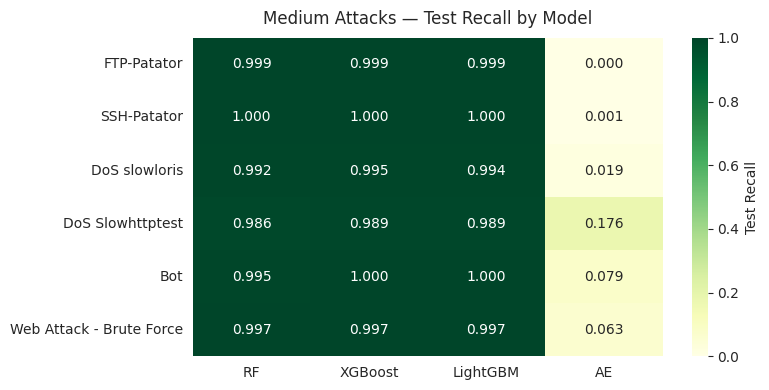

In [ ]:
heatmap_data = pd.DataFrame(
    {m: [results[a][m]['test_recall'] for a in medium_attacks] for m in MODELS},
    index=medium_attacks
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, cbar_kws={'label': 'Test Recall'}, ax=ax)
ax.set_title('Medium Attacks — Test Recall by Model', pad=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/results_medium_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()